# Практическая работа 5

**Тема**: Анализ временных рядов.
**Цель работы**: Знакомство с технологией хранения и анализа временных рядов.

## Настройка зависимостей

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Задание 1. Велосипеды в Сиэтле

Набор данных [Fremont_Bridge_Bicycle_Counter.csv](./Fremont_Bridge_Bicycle_Counter.csv) содержит сведения о количестве велосипедов, проезжающих по Фримонтском мосту в Сиэтле. Эти данные поступают из автоматического счетчика велосипедов, установленного в конце 2012 года с индуктивными датчиками на восточной и западной боковых дорожках моста.

Ваша задача:

1. Представить данный набор данных в виде датафрейма, сократив названия столбцов

In [2]:
bicycles = pd.read_csv(
  "Fremont_Bridge_Bicycle_Counter.csv",
  date_format="%m/%d/%Y %I:%M:%S %p",
  index_col="Date",
  names=["Date", "Total", "East", "West"],
  header=0,
)

bicycles.head()

,Total,East,West
Date,,,
2022-08-01 00:00:00,23.0,7.0,16.0
2022-08-01 01:00:00,12.0,5.0,7.0
2022-08-01 02:00:00,3.0,0.0,3.0
2022-08-01 03:00:00,5.0,2.0,3.0
2022-08-01 04:00:00,10.0,2.0,8.0


2. Проанализировать сводные статистические показатели для этих данных.

In [3]:
bicycles.describe()

,Total,East,West
count,91210.000000,91210.000000,91210.000000
mean,105.603859,47.193882,58.409977
std,133.270779,60.779588,82.619206
min,0.000000,0.000000,0.000000
25%,13.000000,6.000000,7.000000
50%,58.000000,26.000000,30.000000
75%,142.000000,65.000000,75.000000
max,1097.000000,698.000000,850.000000


3. Сделайте выборку данных за последние 3 года.

In [4]:
bicycles[bicycles.index >= bicycles.index.max() - pd.DateOffset(years=3)].sort_index(ascending=False)

,Total,East,West
Date,,,
2023-02-28 23:00:00,6.0,3.0,3.0
2023-02-28 22:00:00,14.0,5.0,9.0
2023-02-28 21:00:00,30.0,13.0,17.0
2023-02-28 20:00:00,37.0,22.0,15.0
2023-02-28 19:00:00,59.0,19.0,40.0
...,...,...,...
2020-02-29 03:00:00,2.0,0.0,2.0
2020-02-29 02:00:00,5.0,2.0,3.0
2020-02-29 01:00:00,1.0,1.0,0.0


4. С помощью метода `resample` выполните передискретизацию выборки с шагом одна неделя и постройте график. Какой можно сделать вывод об использовании велосипедов?

<Axes: title={'center': 'Использование велосипедов по неделям'}, xlabel='Дата', ylabel='Количество велосипедистов'>

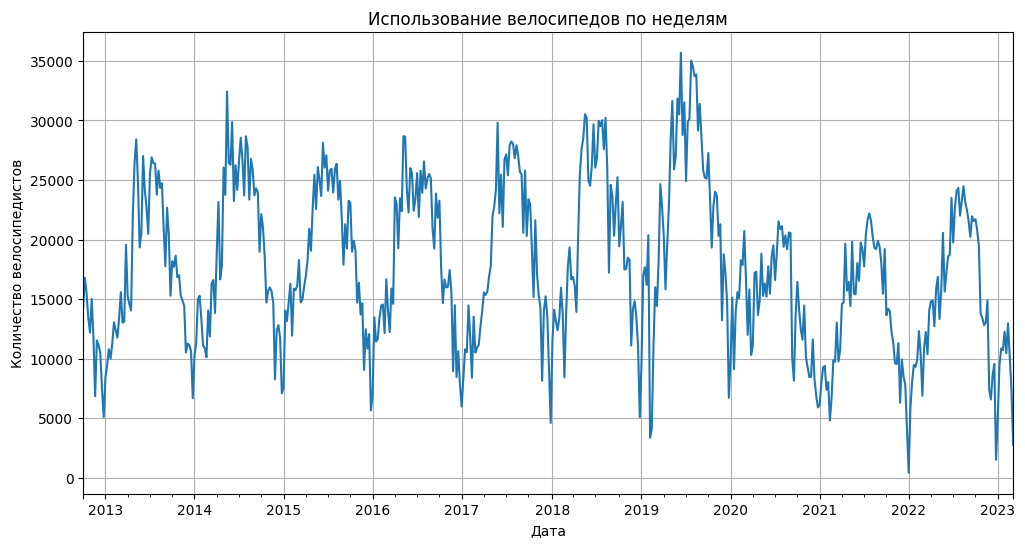

In [5]:
bicycles.resample("W").sum()["Total"].plot(
  figsize=(12, 6),
  title="Использование велосипедов по неделям",
  xlabel="Дата",
  ylabel="Количество велосипедистов",
  grid=True,
)

**Вывод**: на графике можно заметить сезонность:

- зимой - минимум;
- весной - рост;
- летом - максимум;
- осенью - спад.

Также можно заметить снижение числа велосипедистов в 2020 году и после.
Причиной этому послужила пандемия COVID-19.

5. Выполните передискретизацию выборки с шагом один месяц и постройте график. Сравните полученные графики.

<Axes: title={'center': 'Использование велосипедов по месяцам'}, xlabel='Дата', ylabel='Количество велосипедистов'>

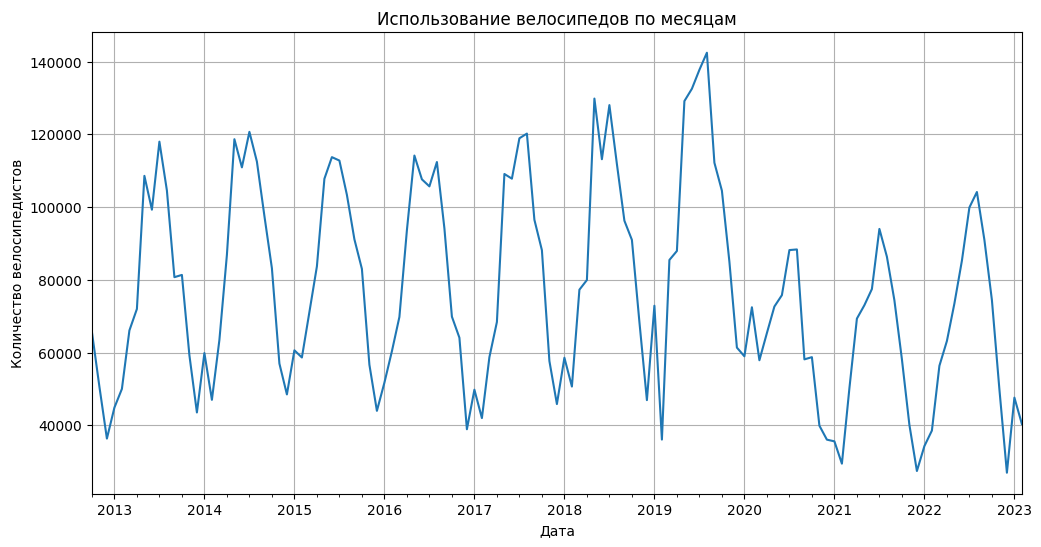

In [6]:
bicycles.resample("ME").sum()["Total"].plot(
  figsize=(12, 6),
  title="Использование велосипедов по месяцам",
  xlabel="Дата",
  ylabel="Количество велосипедистов",
  grid=True,
)

**Вывод**: график с шагом в 1 месяц состоит из ряда с более низкой частотой,
из-за чего кривая более сглаженная, чем на графике с шагом в 1 неделю.

6. Выполните передискретизацию выборки с шагом один день и с помощью функции `pd.rolling` вычислите скользящее среднее за 30 дней, центрируя при этом окно. Постройте график.

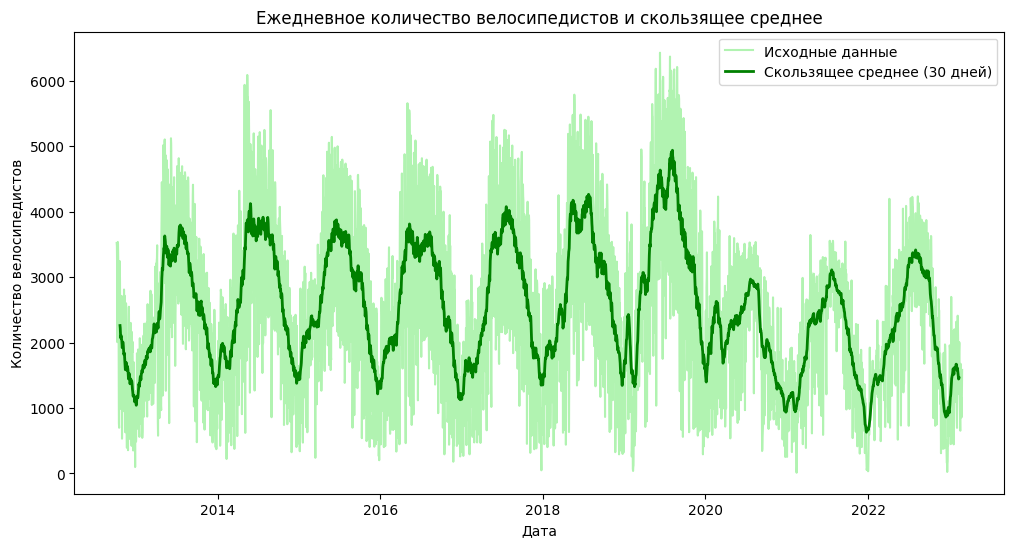

In [7]:
daily_bicycles = bicycles.resample("D").sum()

rolling_mean_30 = daily_bicycles["Total"].rolling(window=30, center=True).mean()

plt.figure(figsize=(12, 6))

plt.plot(
  daily_bicycles.index,
  daily_bicycles["Total"],
  label="Исходные данные",
  color="lightgreen",
  alpha=0.7,
)
plt.plot(
  rolling_mean_30.index,
  rolling_mean_30,
  label="Скользящее среднее (30 дней)",
  color="green",
  linewidth=2,
)

plt.title("Ежедневное количество велосипедистов и скользящее среднее")
plt.xlabel("Дата")
plt.ylabel("Количество велосипедистов")
plt.legend()
plt.show()

7. Попробуйте получить более гладкую версию скользящего среднего.

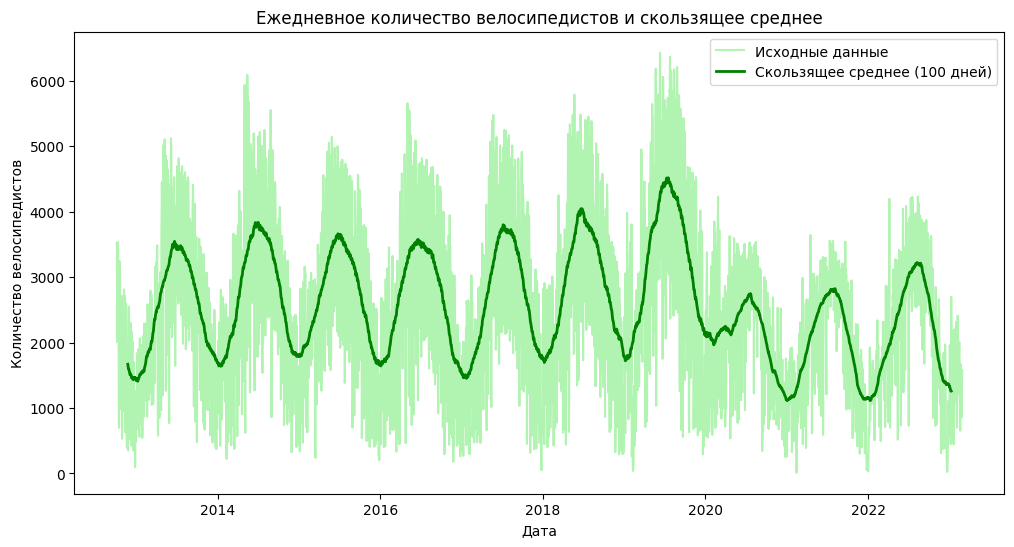

In [8]:
rolling_mean_100 = daily_bicycles["Total"].rolling(window=100, center=True).mean()

plt.figure(figsize=(12, 6))

plt.plot(
  daily_bicycles.index,
  daily_bicycles["Total"],
  label="Исходные данные",
  color="lightgreen",
  alpha=0.7,
)
plt.plot(
  rolling_mean_100.index,
  rolling_mean_100,
  label="Скользящее среднее (100 дней)",
  color="green",
  linewidth=2,
)

plt.title("Ежедневное количество велосипедистов и скользящее среднее")
plt.xlabel("Дата")
plt.ylabel("Количество велосипедистов")
plt.legend()
plt.show()

## Задание 2.
Приведите свой пример на использование временных рядов. Продемонстрируйте возможности работы с временными рядами, представленные в лекции (Создание временного ряда с определенной частотой, вычисление новых дат с помощью смещений, преобразование в определенный часовой пояс, увеличение или уменьшение шага дискретизации временного ряда и др.).

**Пример**: Анализ уровня осадков за 2021 год

- cоздание временного ряда с определенной частотой

In [9]:
date_rng = pd.date_range("2021-01-01", "2021-12-31", freq="h")

np.random.seed(420)
precipitation_level_records = np.random.uniform(0, 0.2, len(date_rng))

precipitation_level = pd.DataFrame({
  "Дата": date_rng,
  "Осадки (мм)": precipitation_level_records
}).set_index("Дата")

precipitation_level.head()

,Осадки (мм)
Дата,
2021-01-01 00:00:00,0.063129
2021-01-01 01:00:00,0.090606
2021-01-01 02:00:00,0.053396
2021-01-01 03:00:00,0.021786
2021-01-01 04:00:00,0.173633


- вычисление новых дат с помощью смещений

In [10]:
precipitation_level.shift(7, freq='h').head()

,Осадки (мм)
Дата,
2021-01-01 07:00:00,0.063129
2021-01-01 08:00:00,0.090606
2021-01-01 09:00:00,0.053396
2021-01-01 10:00:00,0.021786
2021-01-01 11:00:00,0.173633


- преобразование в определенный часовой пояс

In [11]:
precipitation_level = precipitation_level.tz_localize("UTC").tz_convert("Europe/Moscow")

precipitation_level.head()

,Осадки (мм)
Дата,
2021-01-01 03:00:00+03:00,0.063129
2021-01-01 04:00:00+03:00,0.090606
2021-01-01 05:00:00+03:00,0.053396
2021-01-01 06:00:00+03:00,0.021786
2021-01-01 07:00:00+03:00,0.173633


- увеличение или уменьшение шага дискретизации временного ряда

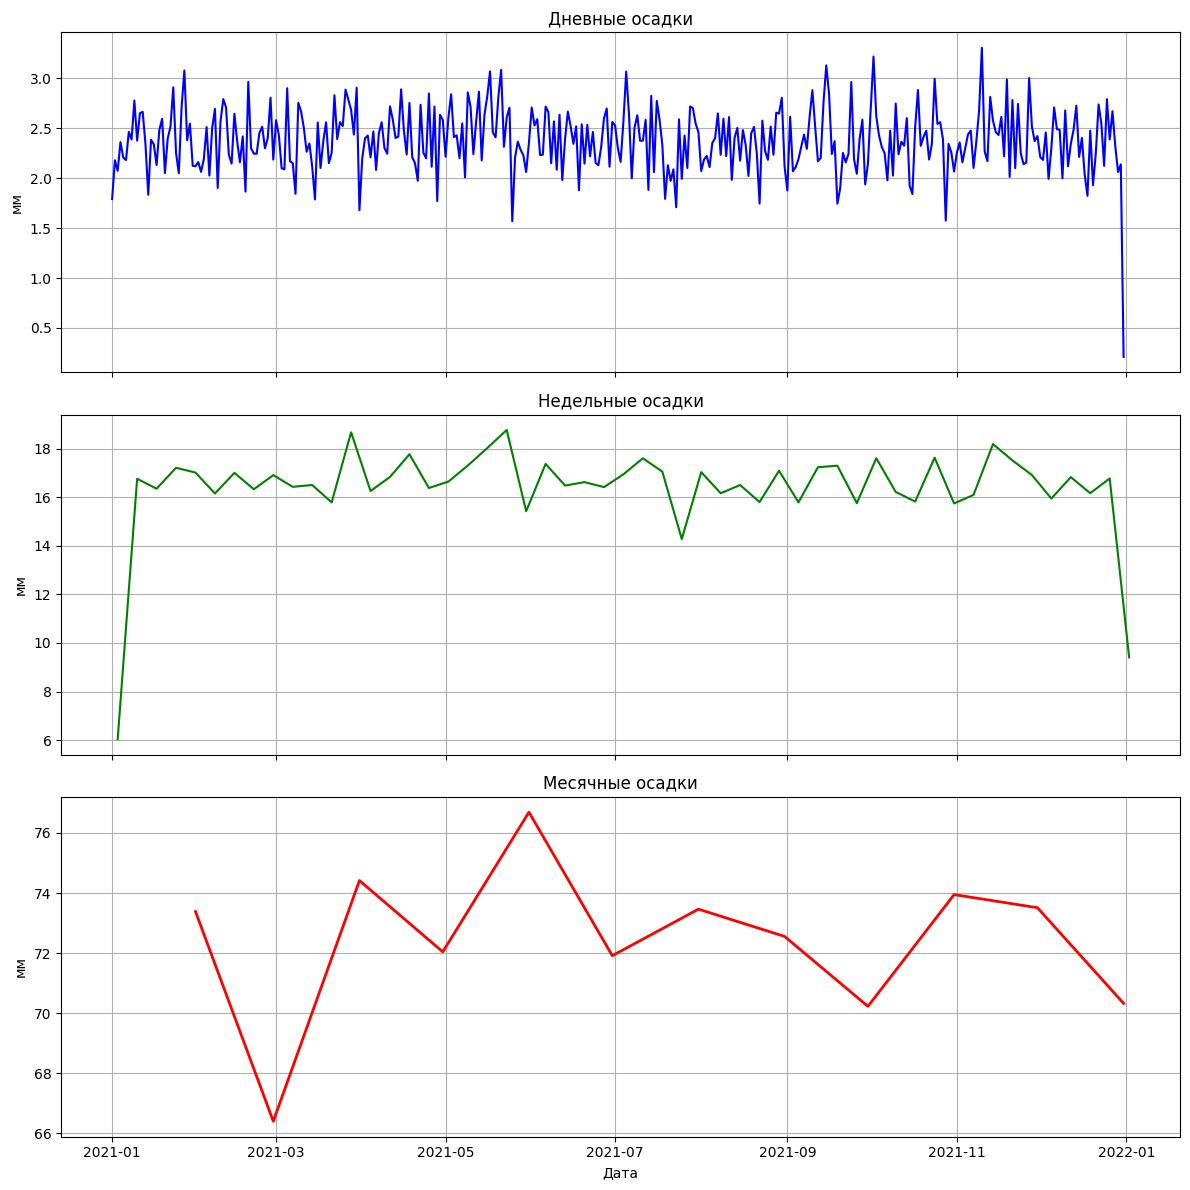

In [12]:
precipitation_daily = precipitation_level.resample("D").sum()
precipitation_weekly = precipitation_level.resample("W").sum()
precipitation_monthly = precipitation_level.resample("ME").sum()

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

axes[0].plot(
  precipitation_daily.index,
  precipitation_daily["Осадки (мм)"],
  color="blue"
)
axes[0].set_title("Дневные осадки")
axes[0].set_ylabel("мм")
axes[0].grid()

axes[1].plot(
  precipitation_weekly.index,
  precipitation_weekly["Осадки (мм)"],
  color="green"
)
axes[1].set_title("Недельные осадки")
axes[1].set_ylabel("мм")
axes[1].grid()

axes[2].plot(
  precipitation_monthly.index,
  precipitation_monthly["Осадки (мм)"],
  color="red",
  linewidth=2,
)
axes[2].set_title("Месячные осадки")
axes[2].set_ylabel("мм")
axes[2].set_xlabel("Дата")
axes[2].grid()

plt.tight_layout()
plt.show()

## Экспорт в html

In [13]:
from os import system
system(f"jupyter nbconvert --to html {__vsc_ipynb_file__}")

[NbConvertApp] Converting notebook /Users/efim/dev/university-6sem-data-analysis/topic5/practice5/practice5.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 959980 bytes to /Users/efim/dev/university-6sem-data-analysis/topic5/practice5/practice5.html


0